# Prédiction de Risque de Sinistre - Assurance Habitation

## Phase 1: EXPLORATORY DATA ANALYSIS (EDA)

Ce notebook contient le preprocessing complet et l'entraînement des modèles de machine learning pour la prédiction du risque de sinistre sur les habitations.

Modèles entraînés: Random Forest, Logistic Regression, Gradient Boosting.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style("whitegrid")

In [62]:
# 1. Chargement des données
print("=" * 60)
print("CHARGEMENT DES DONNÉES")
print("=" * 60)

train = pd.read_csv('train_Insurance.csv')
test = pd.read_csv('test_Insurance.csv')

print(f"\nDataset Train: {train.shape}")
print(f"Dataset Test: {test.shape}")
print(f"\nColonnes: {train.columns.tolist()}")

CHARGEMENT DES DONNÉES

Dataset Train: (5012, 13)
Dataset Test: (2147, 13)

Colonnes: ['Customer Id', 'YearOfObservation', 'Insured_Period', 'Residential', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'Building Dimension', 'Building_Type', 'NumberOfWindows', 'Geo_Code', 'Claim']


In [63]:
# 2. Analyse initiale des données
print("\n" + "=" * 60)
print("APERÇU DES DONNÉES")
print("=" * 60)

print("\n--- Premières lignes ---")
print(train.head())

print("\n--- Types de données ---")
print(train.info())

print("\n--- Statistiques descriptives ---")
print(train.describe(include='all'))


APERÇU DES DONNÉES

--- Premières lignes ---
  Customer Id  YearOfObservation  Insured_Period  Residential  \
0      H13501               2012             1.0            1   
1      H14962               2012             1.0            0   
2      H17755               2013             1.0            1   
3      H13369               2016             0.5            0   
4      H12988               2012             1.0            0   

  Building_Painted Building_Fenced Garden Settlement  Building Dimension  \
0                N               V      V          U              1240.0   
1                N               V      V          U               900.0   
2                V               N      O          R              4984.0   
3                N               V      V          U               600.0   
4                N               V      V          U               900.0   

     Building_Type NumberOfWindows Geo_Code Claim  
0      Wood-framed         without    75117   non  
1 


ANALYSE DES VALEURS MANQUANTES

--- Valeurs manquantes par colonne ---
                    Train  Test  Train %  Test %
Garden                  4     3     0.08    0.14
Building Dimension     77    29     1.54    1.35
Geo_Code               73    29     1.46    1.35

⚠ 154 valeurs manquantes au total


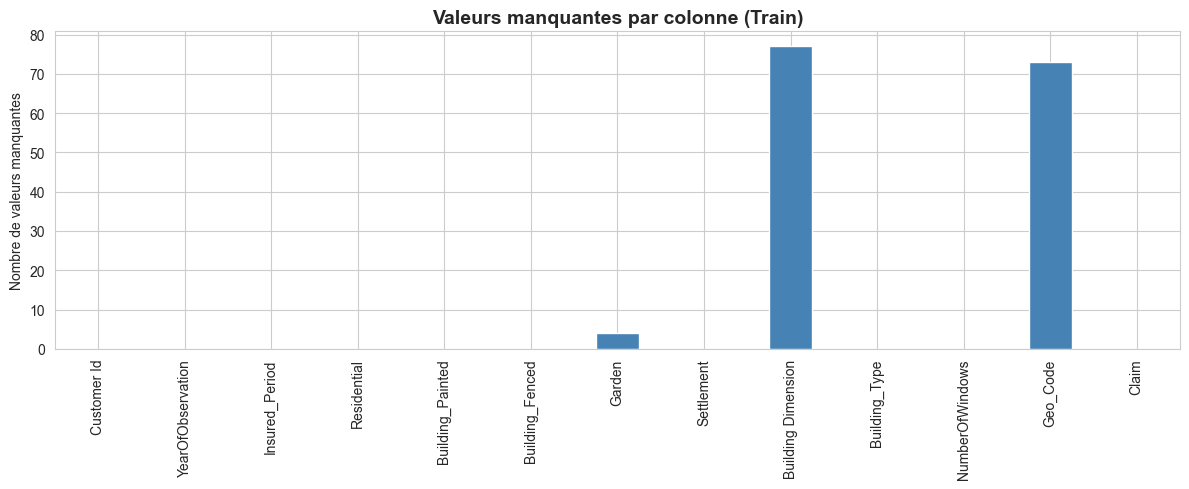

In [64]:
# 3. Analyse des valeurs manquantes
print("\n" + "=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("=" * 60)

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

missing_df = pd.DataFrame({
    'Train': missing_train,
    'Test': missing_test,
    'Train %': (missing_train / len(train) * 100).round(2),
    'Test %': (missing_test / len(test) * 100).round(2)
})

print("\n--- Valeurs manquantes par colonne ---")
print(missing_df[missing_df.sum(axis=1) > 0])

if missing_train.sum() == 0:
    print("\n✓ Aucune valeur manquante dans le dataset d'entraînement")
else:
    print(f"\n⚠ {missing_train.sum()} valeurs manquantes au total")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
missing_train.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Valeurs manquantes par colonne (Train)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de valeurs manquantes')
plt.tight_layout()
plt.show()

In [65]:
# 4. Gestion des valeurs manquantes (STRATÉGIES ADAPTÉES)
print("\n" + "=" * 60)
print("GESTION DES VALEURS MANQUANTES")
print("=" * 60)

def fill_missing_values(df, strategy='adaptive'):
    """
    Remplir les valeurs manquantes avec stratégies adaptées
    - Pour colonnes numériques: médiane (résistant aux outliers)
    - Pour colonnes catégorielles: mode (valeur la plus fréquente)
    """
    df_filled = df.copy()
    
    for col in df_filled.columns:
        if df_filled[col].isnull().sum() > 0:
            if df_filled[col].dtype in ['float64', 'int64']:
                # Numérique: utiliser la médiane
                fill_value = df_filled[col].median()
                df_filled[col].fillna(fill_value, inplace=True)
                print(f"  {col}: rempli avec médiane = {fill_value}")
            else:
                # Catégorique: utiliser le mode
                fill_value = df_filled[col].mode()[0] if len(df_filled[col].mode()) > 0 else 'Unknown'
                df_filled[col].fillna(fill_value, inplace=True)
                print(f"  {col}: rempli avec mode = {fill_value}")
    
    return df_filled

train = fill_missing_values(train)
test = fill_missing_values(test)

print(f"\n✓ Valeurs manquantes restantes (Train): {train.isnull().sum().sum()}")
print(f"✓ Valeurs manquantes restantes (Test): {test.isnull().sum().sum()}")


GESTION DES VALEURS MANQUANTES
  Garden: rempli avec mode = O
  Building Dimension: rempli avec médiane = 1067.0
  Geo_Code: rempli avec mode = 6088
  Garden: rempli avec mode = V
  Building Dimension: rempli avec médiane = 1100.0
  Geo_Code: rempli avec mode = 6088

✓ Valeurs manquantes restantes (Train): 0
✓ Valeurs manquantes restantes (Test): 0


## Phase 2: FEATURE ENGINEERING & ENCODING

### Étapes du preprocessing:
1. **Encodage des variables catégorielles** - Transformation des textes en nombres
2. **Détection d'outliers** - Identification des valeurs aberrantes
3. **Normalisation des features** - Mise à l'échelle des données
4. **Séparation train/validation** - Split stratifié basé sur la cible

In [66]:
# 5. ENCODAGE DES VARIABLES CATÉGORIELLES
print("\n" + "=" * 60)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("=" * 60)

# Afficher les valeurs uniques avant encodage
print("\n--- Valeurs avant encodage ---")
categorical_cols = train.select_dtypes(include='object').columns
for col in categorical_cols:
    if col != 'Customer Id' and col != 'Claim':
        print(f"{col}: {train[col].unique()}")

# Encodage manuel des colonnes booléennes
print("\n--- Encodage manuel ---")
for df in [train, test]:
    # Gestion de NumberOfWindows
    if 'NumberOfWindows' in df.columns:
        df['NumberOfWindows'] = df['NumberOfWindows'].astype(str).replace({'without': 0, '>=10': 10})
        df['NumberOfWindows'] = pd.to_numeric(df['NumberOfWindows'], errors='coerce').fillna(0).astype(int)
        print(f"NumberOfWindows: {df['NumberOfWindows'].unique()}")
    
    # Variables booléennes N/V (N=Oui, V=Non)
    for col in ['Building_Painted', 'Building_Fenced']:
        if col in df.columns:
            df[col] = df[col].map({'N': 1, 'V': 0})
    
    # Variables V/O (V=Oui, O=Non)
    for col in ['Garden']:
        if col in df.columns:
            df[col] = df[col].map({'V': 1, 'O': 0})
    
    # Variables U/R (Urban/Rural)
    for col in ['Settlement']:
        if col in df.columns:
            df[col] = df[col].map({'U': 1, 'R': 0})

print("✓ Colonnes booléennes encodées")

# Encodage LabelEncoder pour les colonnes catégorielles restantes
print("\n--- Encodage LabelEncoder ---")
features_train_df = train.drop(['Customer Id', 'Claim'], axis=1)
target_series = train['Claim'].map({'oui': 1, 'non': 0}) if 'Claim' in train.columns else None
features_test_df = test.drop(['Customer Id'], axis=1)

cat_cols = features_train_df.select_dtypes(include='object').columns.tolist()
label_encoders = {}

for col in cat_cols:
    print(f"  Encodage {col}...")
    le = LabelEncoder()
    # Combiner train et test pour consistent encoding
    combined_data = pd.concat([features_train_df[col], features_test_df[col]], ignore_index=True)
    le.fit(combined_data)
    features_train_df[col] = le.transform(features_train_df[col])
    features_test_df[col] = le.transform(features_test_df[col])
    label_encoders[col] = le

# Encodeur spécial pour Building_Type
if 'Building_Type' in features_train_df.columns:
    le_type = LabelEncoder()
    le_type.fit(features_train_df['Building_Type'])
    joblib.dump(le_type, "building_type_encoder.pkl")
    print("✓ Encodeur Building_Type sauvegardé")

print(f"\n✓ {len(cat_cols)} colonnes catégorielles encodées")
print(f"✓ Features d'entraînement (dataframe) shape: {features_train_df.shape}")


ENCODAGE DES VARIABLES CATÉGORIELLES

--- Valeurs avant encodage ---
Building_Painted: ['N' 'V']
Building_Fenced: ['V' 'N']
Garden: ['V' 'O']
Settlement: ['U' 'R']
Building_Type: ['Wood-framed' 'Non-combustible' 'Ordinary' 'Fire-resistive']
NumberOfWindows: ['without' '4' '2' '7' '5' '3' '8' '>=10' '6' '1' '9']
Geo_Code: ['75117' '62916' '31149' ... '45232' '42225' '94059']

--- Encodage manuel ---
NumberOfWindows: [ 0  4  2  7  5  3  8 10  6  1  9]
NumberOfWindows: [ 0  5  6  9  7  3  8  4  1  2 10]
✓ Colonnes booléennes encodées

--- Encodage LabelEncoder ---
  Encodage Building_Type...
  Encodage Geo_Code...
✓ Encodeur Building_Type sauvegardé

✓ 2 colonnes catégorielles encodées
✓ Features d'entraînement (dataframe) shape: (5012, 11)


In [67]:
# 6. DÉTECTION D'OUTLIERS (IQR Method)
print("\n" + "=" * 60)
print("DÉTECTION D'OUTLIERS")
print("=" * 60)

def detect_outliers_iqr(df, columns=None):
    """
    Détecte les outliers en utilisant la méthode IQR
    (Interquartile Range)
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns
    
    outliers_count = 0
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        col_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        if col_outliers > 0:
            outliers_count += col_outliers
            print(f"  {col}: {col_outliers} outliers (intervalle: [{lower:.2f}, {upper:.2f}])")
    
    return outliers_count

numeric_feature_cols = features_train_df.select_dtypes(include=[np.number]).columns
outliers_found = detect_outliers_iqr(features_train_df, numeric_feature_cols)
print(f"\n⚠ Total outliers trouvés: {outliers_found}")
print("Note: Les outliers ne sont pas supprimés (peuvent être importants)")

# 7. NORMALISATION DES FEATURES
print("\n" + "=" * 60)
print("NORMALISATION DES FEATURES")
print("=" * 60)

# Remplir les NaN potentielles
features_train_df = features_train_df.fillna(0)
features_test_df = features_test_df.fillna(0)

# S'assurer que features_test_df a les mêmes colonnes que features_train_df
features_test_df = features_test_df[features_train_df.columns]

scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train_df)
features_test_scaled = scaler.transform(features_test_df)

print(f"✓ Features normalisées (mean=0, std=1)")
print(f"  features_train_scaled shape: {features_train_scaled.shape}")
print(f"  features_test_scaled shape: {features_test_scaled.shape}")

# Sauvegarder le scaler
joblib.dump(scaler, "feature_scaler.pkl")
print("✓ Scaler sauvegardé pour utilisation en production")

# 8. SPLIT TRAIN/VALIDATION
print("\n" + "=" * 60)
print("SÉPARATION TRAIN/VALIDATION")
print("=" * 60)

train_features, val_features, train_target, val_target = train_test_split(
    features_train_scaled, target_series, test_size=0.2, random_state=42, stratify=target_series
)

print(f"train_features: {train_features.shape}")
print(f"val_features: {val_features.shape}")
print(f"train_target: classe 0 = {(train_target == 0).sum()}, classe 1 = {(train_target == 1).sum()}")
print(f"val_target: classe 0 = {(val_target == 0).sum()}, classe 1 = {(val_target == 1).sum()}")

# Sauvegarder les données de validation
joblib.dump(val_features, 'X_val.pkl')
joblib.dump(val_target, 'y_val.pkl')
print("\n✓ Données de validation sauvegardées")


DÉTECTION D'OUTLIERS
  Building_Painted: 1249 outliers (intervalle: [0.00, 0.00])
  Building Dimension: 397 outliers (intervalle: [-2050.00, 4830.00])

⚠ Total outliers trouvés: 1646
Note: Les outliers ne sont pas supprimés (peuvent être importants)

NORMALISATION DES FEATURES
✓ Features normalisées (mean=0, std=1)
  features_train_scaled shape: (5012, 11)
  features_test_scaled shape: (2147, 11)
✓ Scaler sauvegardé pour utilisation en production

SÉPARATION TRAIN/VALIDATION
train_features: (4009, 11)
val_features: (1003, 11)
train_target: classe 0 = 3108, classe 1 = 901
val_target: classe 0 = 778, classe 1 = 225

✓ Données de validation sauvegardées

DÉTECTION D'OUTLIERS
  Building_Painted: 1249 outliers (intervalle: [0.00, 0.00])
  Building Dimension: 397 outliers (intervalle: [-2050.00, 4830.00])

⚠ Total outliers trouvés: 1646
Note: Les outliers ne sont pas supprimés (peuvent être importants)

NORMALISATION DES FEATURES
✓ Features normalisées (mean=0, std=1)
  features_train_scale

## Phase 3: MODEL TRAINING & EVALUATION

### Stratégie d'entraînement:
- **Random Forest**: Robuste aux outliers, capture les interactions
- **Logistic Regression**: Baseline simple et interprétable
- **Gradient Boosting**: Boosting des erreurs, performant sur données tabulaires
- **Comparaison**: AUC, Precision, Recall, F1-Score

In [68]:
# 9. ENTRAÎNEMENT DES MODÈLES
print('\n' + '=' * 60)
print('ENTRAÎNEMENT DES MODÈLES')
print('=' * 60)

# Modèle 1: Random Forest
print('\n--- RANDOM FOREST ---')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Gère le déséquilibre des classes
)
rf.fit(train_features, train_target)

# Prédictions
rf_pred_labels = rf.predict(val_features)
rf_pred_proba = rf.predict_proba(val_features)[:, 1]

# Métriques
rf_auc = roc_auc_score(val_target, rf_pred_proba)
print(f'AUC-ROC: {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(val_target, rf_pred_labels))

# Importance des features
rf_feature_importance_df = pd.DataFrame({
    'feature': features_train_df.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 10 features:')
print(rf_feature_importance_df.head(10))

# Sauvegarder le modèle
joblib.dump(rf, 'random_forest_model.pkl')
print('\n✓ Modèle Random Forest sauvegardé')

# Modèle 2: Régression Logistique
print('\n--- LOGISTIC REGRESSION ---')
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
lr.fit(train_features, train_target)

# Prédictions
lr_pred_labels = lr.predict(val_features)
lr_pred_proba = lr.predict_proba(val_features)[:, 1]

# Métriques
lr_auc = roc_auc_score(val_target, lr_pred_proba)
print(f'AUC-ROC: {lr_auc:.4f}')
print('\nClassification Report:')
print(classification_report(val_target, lr_pred_labels))

print('\n✓ Modèle Logistic Regression entraîné')

# Modèle 3: Gradient Boosting
print('\n--- GRADIENT BOOSTING ---')
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(train_features, train_target)

# Prédictions
gb_pred_labels = gb.predict(val_features)
gb_pred_proba = gb.predict_proba(val_features)[:, 1]

# Métriques
gb_auc = roc_auc_score(val_target, gb_pred_proba)
print(f'AUC-ROC: {gb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(val_target, gb_pred_labels))

# Sauvegarder le modèle
joblib.dump(gb, 'gradient_boosting_model.pkl')
print('\n✓ Modèle Gradient Boosting sauvegardé')


ENTRAÎNEMENT DES MODÈLES

--- RANDOM FOREST ---
AUC-ROC: 0.6931

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       778
           1       0.41      0.48      0.44       225

    accuracy                           0.73      1003
   macro avg       0.62      0.64      0.63      1003
weighted avg       0.74      0.73      0.73      1003


Top 10 features:
               feature  importance
7   Building Dimension    0.468349
10            Geo_Code    0.199085
9      NumberOfWindows    0.091126
0    YearOfObservation    0.077664
8        Building_Type    0.070781
1       Insured_Period    0.032762
2          Residential    0.023298
3     Building_Painted    0.015434
4      Building_Fenced    0.007550
6           Settlement    0.007321
AUC-ROC: 0.6931

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       778
           1       0.41      0.4


VISUALISATIONS


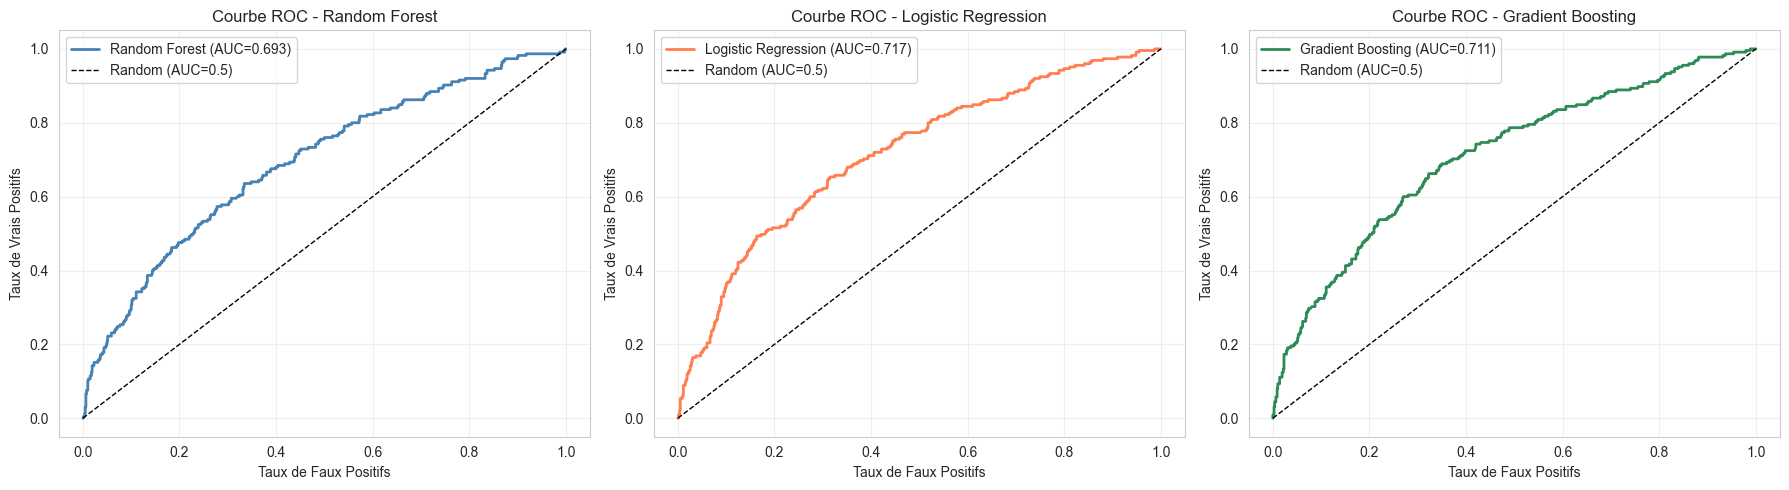

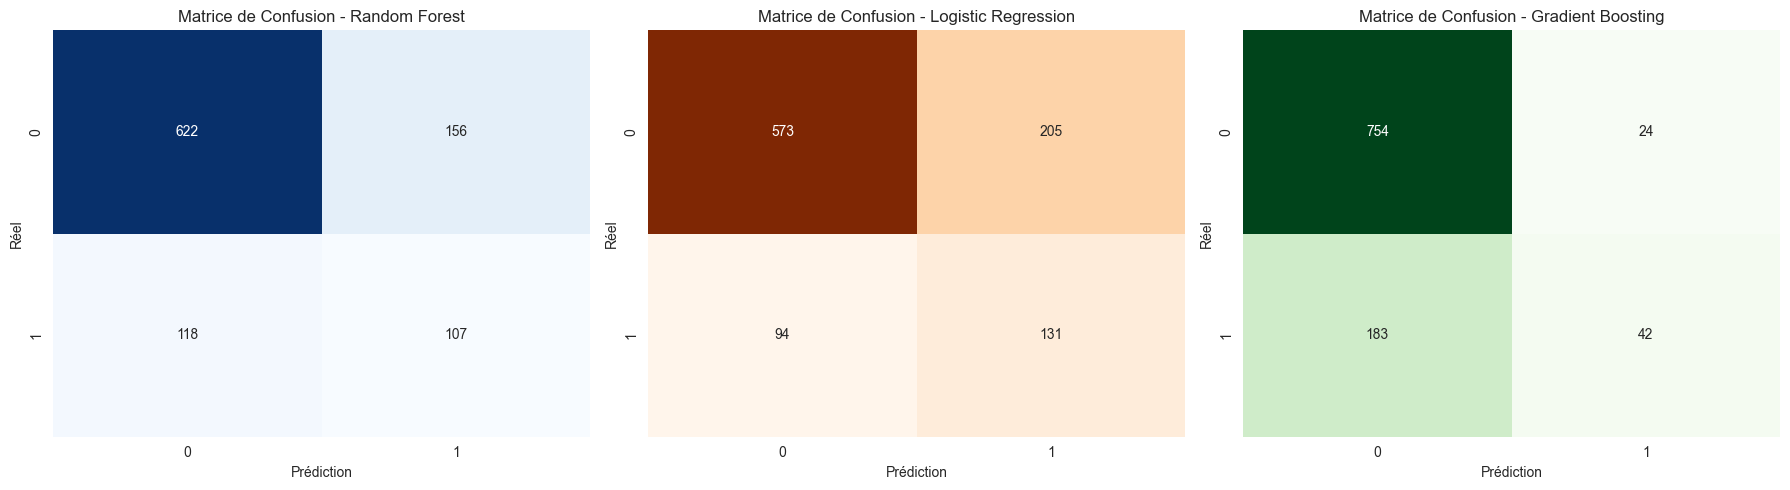

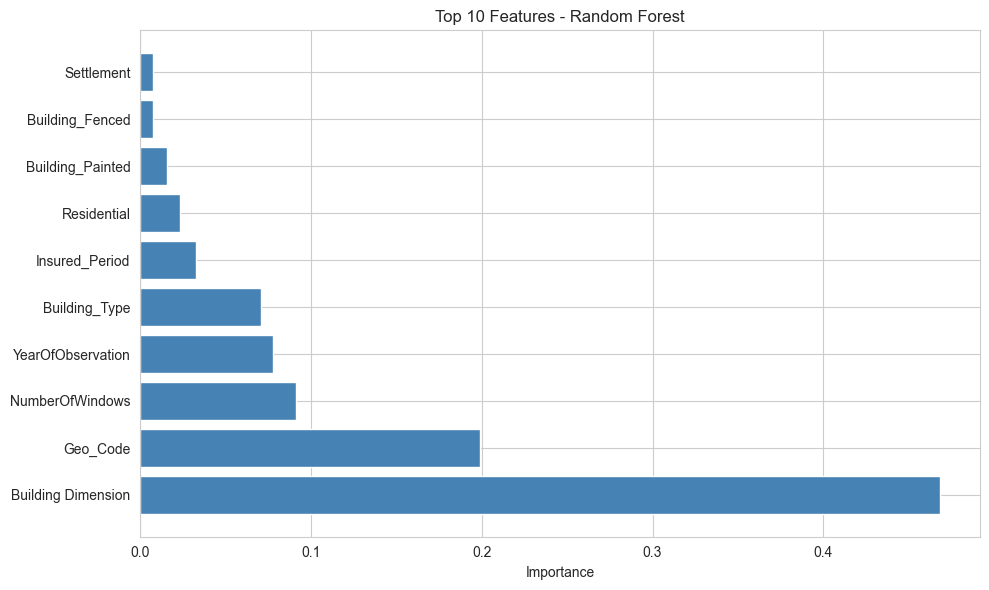


✓ Visualisations complétées


In [69]:
# 10. VISUALISATIONS DE COMPARAISON
print("\n" + "=" * 60)
print("VISUALISATIONS")
print("=" * 60)

# Figure 1: Courbes ROC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe ROC Random Forest
fpr_rf, tpr_rf, _ = roc_curve(val_target, rf_pred_proba)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=2, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1)
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbe ROC - Random Forest')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe ROC Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(val_target, lr_pred_proba)
axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1)
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC - Logistic Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Courbe ROC Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(val_target, gb_pred_proba)
axes[2].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={gb_auc:.3f})', linewidth=2, color='seagreen')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', linewidth=1)
axes[2].set_xlabel('Taux de Faux Positifs')
axes[2].set_ylabel('Taux de Vrais Positifs')
axes[2].set_title('Courbe ROC - Gradient Boosting')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 2: Matrice de Confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CM Random Forest
cm_rf = confusion_matrix(val_target, rf_pred_labels)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matrice de Confusion - Random Forest')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédiction')

# CM Logistic Regression
cm_lr = confusion_matrix(val_target, lr_pred_labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Matrice de Confusion - Logistic Regression')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédiction')

# CM Gradient Boosting
cm_gb = confusion_matrix(val_target, gb_pred_labels)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title('Matrice de Confusion - Gradient Boosting')
axes[2].set_ylabel('Réel')
axes[2].set_xlabel('Prédiction')

plt.tight_layout()
plt.show()

# Figure 3: Feature Importance (Top 10)
fig, ax = plt.subplots(figsize=(10, 6))
top_features = rf_feature_importance_df.head(10)
ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 10 Features - Random Forest')
plt.tight_layout()
plt.show()

print("\n✓ Visualisations complétées")

In [70]:
# 11. SAUVEGARDE DES MODÈLES FINAUX
print("\n" + "=" * 60)
print("SAUVEGARDE DES MODÈLES")
print("=" * 60)

# Sauvegarder la Logistic Regression
joblib.dump(lr, 'logistic_regression_model.pkl')
print("✓ Modèle Logistic Regression sauvegardé")

# Résumé des fichiers sauvegardés
import os
print("\n--- Fichiers sauvegardés (pour production) ---")
files_to_check = [
    'random_forest_model.pkl',
    'logistic_regression_model.pkl',
    'gradient_boosting_model.pkl',
    'feature_scaler.pkl',
    'building_type_encoder.pkl',
    'X_val.pkl',
    'y_val.pkl'
]

for file in files_to_check:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024  # Taille en KB
        print(f"✓ {file} ({size:.2f} KB)")
    else:
        print(f"✗ {file} (manquant)")

print("\n" + "=" * 60)
print("✓ PREPROCESSING ET ENTRAÎNEMENT COMPLÉTÉS")
print("=" * 60)
print("\nLes modèles sont prêts pour le déploiement!")
print("Utilisez app.py pour créer une API Flask.")



SAUVEGARDE DES MODÈLES
✓ Modèle Logistic Regression sauvegardé

--- Fichiers sauvegardés (pour production) ---
✓ random_forest_model.pkl (3068.74 KB)
✓ logistic_regression_model.pkl (0.95 KB)
✓ gradient_boosting_model.pkl (189.46 KB)
✓ feature_scaler.pkl (1.34 KB)
✓ building_type_encoder.pkl (0.35 KB)
✓ X_val.pkl (86.43 KB)
✓ y_val.pkl (32.13 KB)

✓ PREPROCESSING ET ENTRAÎNEMENT COMPLÉTÉS

Les modèles sont prêts pour le déploiement!
Utilisez app.py pour créer une API Flask.
